In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_excel("Online Retail.xlsx")
print(df.head())
print("Shape:", df.shape)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
Shape: (541909, 8)


In [3]:
print(df.info())
print(df.describe())
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.0000

In [4]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [5]:
df = df.dropna(subset=["Description", "CustomerID"])
print(df.isnull().sum())
print("Shape:", df.shape)

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64
Shape: (406829, 8)


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5225


In [7]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (401604, 8)


In [8]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
print("Shape:", df.shape)

Shape: (392732, 8)


In [9]:
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]
print("Shape:", df.shape)

Shape: (392692, 8)


In [10]:
df["TotalSales"] = df["Quantity"] * df["UnitPrice"]
print(df[["Description", "Quantity", "UnitPrice", "TotalSales"]].head())

                           Description  Quantity  UnitPrice  TotalSales
0   WHITE HANGING HEART T-LIGHT HOLDER         6       2.55       15.30
1                  WHITE METAL LANTERN         6       3.39       20.34
2       CREAM CUPID HEARTS COAT HANGER         8       2.75       22.00
3  KNITTED UNION FLAG HOT WATER BOTTLE         6       3.39       20.34
4       RED WOOLLY HOTTIE WHITE HEART.         6       3.39       20.34


In [12]:
#EDA
top_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


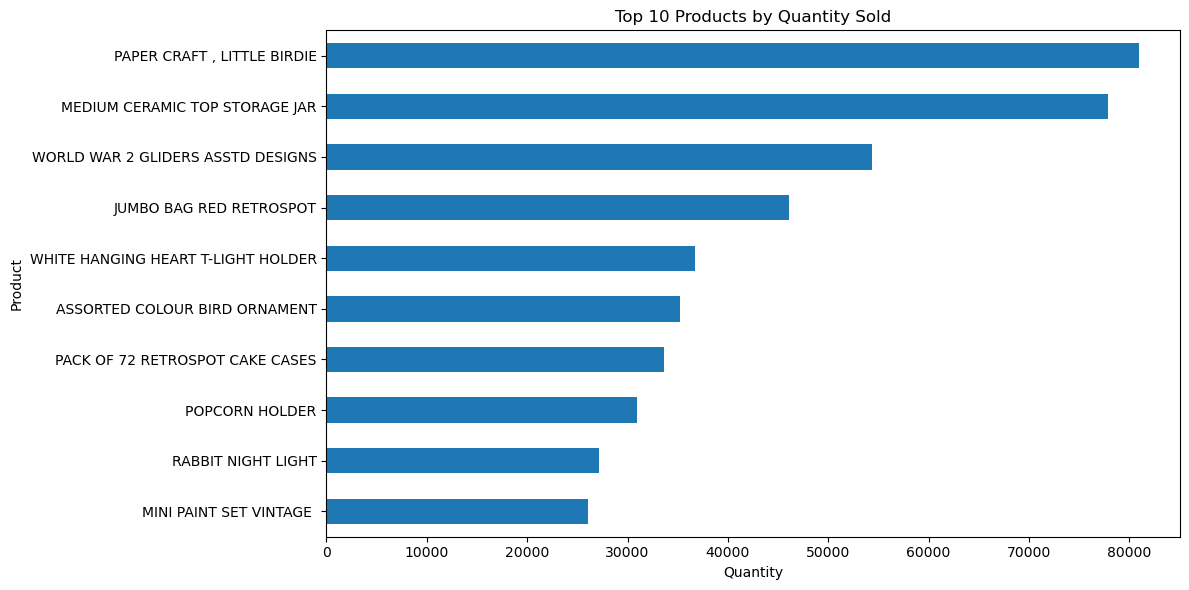

In [13]:
plt.figure(figsize=(12, 6))
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [14]:
top_sales = (
    df.groupby("Description")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(top_sales)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: TotalSales, dtype: float64


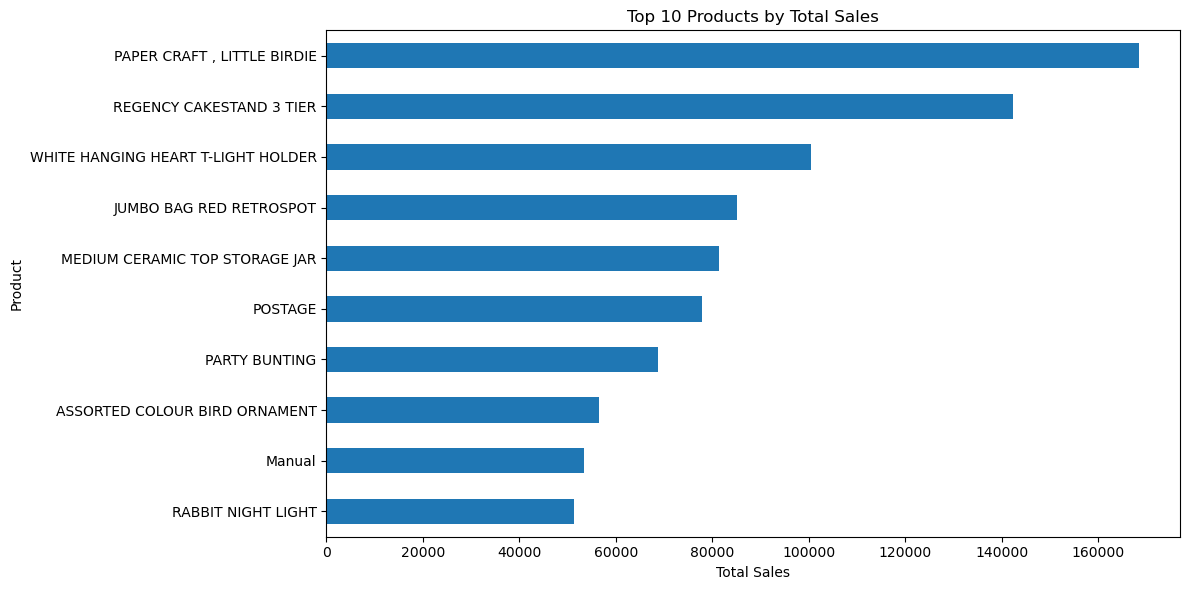

In [15]:
plt.figure(figsize=(12, 6))
top_sales.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [16]:
country_sales = (
    df.groupby("Country")["TotalSales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(country_sales)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalSales, dtype: float64


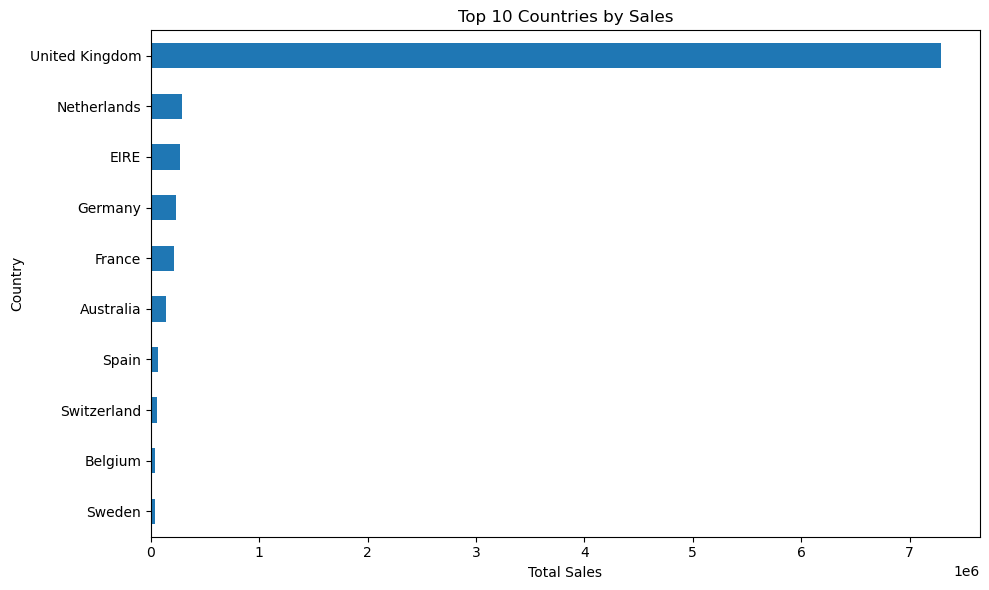

In [18]:
plt.figure(figsize=(10, 6))
country_sales.sort_values().plot(kind="barh")
plt.title("Top 10 Countries by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [19]:
#KNN
customer_product = df.pivot_table(
    index="CustomerID",
    columns="Description",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)
print(customer_product.shape)

(4338, 3877)


In [20]:
product_count = (customer_product > 0).sum(axis=0)
popular_products = product_count[
    product_count >= 5
].index
customer_product = customer_product[
    popular_products
]
print("Matrix shape:", customer_product.shape)

Matrix shape: (4338, 3260)


In [21]:
customer_count = (customer_product > 0).sum(axis=1)
active_customers = customer_count[
    customer_count >= 2
].index
customer_product = customer_product.loc[
    active_customers
]
print("Final matrix shape:", customer_product.shape)

Final matrix shape: (4245, 3260)


In [22]:
product_customer = customer_product.T
print("Product-Customer matrix:")
print(product_customer.shape)

Product-Customer matrix:
(3260, 4245)


In [23]:
scaler = StandardScaler()
product_customer_scaled = scaler.fit_transform(
    product_customer
)

In [24]:
knn = NearestNeighbors(
    metric="cosine",
    algorithm="brute"
)
knn.fit(product_customer_scaled)
print("KNN model trained successfully!")

KNN model trained successfully!


In [25]:
def recommend_products(product_name, n=5):
    if product_name not in product_customer.index:
        print("Product not found.")
        return
    product_index = product_customer.index.get_loc(
        product_name
    )

    distances, indices = knn.kneighbors(
        product_customer_scaled[product_index].reshape(1, -1),
        n_neighbors=n + 1
    )

    print("\nSelected Product:")
    print(product_name)

    print("\nRecommended Products:")

    for i in range(1, len(indices[0])):

        recommended_product = product_customer.index[
            indices[0][i]
        ]

        similarity = 1 - distances[0][i]

        print(
            f"{i}. {recommended_product}"
            f" | Similarity: {similarity:.2f}"
        )

In [26]:
print(product_customer.index[:20].tolist())

[' 4 PURPLE FLOCK DINNER CANDLES', " 50'S CHRISTMAS GIFT BAG LARGE", ' DOLLY GIRL BEAKER', ' I LOVE LONDON MINI BACKPACK', ' NINE DRAWER OFFICE TIDY', ' OVAL WALL MIRROR DIAMANTE ', ' RED SPOT GIFT BAG LARGE', ' SET 2 TEA TOWELS I LOVE LONDON ', ' SPACEBOY BABY GIFT SET', ' TRELLIS COAT RACK', '10 COLOUR SPACEBOY PEN', '12 COLOURED PARTY BALLOONS', '12 DAISY PEGS IN WOOD BOX', '12 EGG HOUSE PAINTED WOOD', '12 HANGING EGGS HAND PAINTED', '12 IVORY ROSE PEG PLACE SETTINGS', '12 MESSAGE CARDS WITH ENVELOPES', '12 PENCIL SMALL TUBE WOODLAND', '12 PENCILS SMALL TUBE RED RETROSPOT', '12 PENCILS SMALL TUBE SKULL']


In [27]:
recommend_products(
    "WHITE HANGING HEART T-LIGHT HOLDER",
    5
)


Selected Product:
WHITE HANGING HEART T-LIGHT HOLDER

Recommended Products:
1. RED HANGING HEART T-LIGHT HOLDER | Similarity: 0.42
2. CANDLEHOLDER PINK HANGING HEART | Similarity: 0.35
3. HEART OF WICKER LARGE | Similarity: 0.21
4. WOODEN PICTURE FRAME WHITE FINISH | Similarity: 0.21
5. SMALL WHITE HEART OF WICKER | Similarity: 0.18


In [28]:
print(product_customer.index[:20].tolist())

[' 4 PURPLE FLOCK DINNER CANDLES', " 50'S CHRISTMAS GIFT BAG LARGE", ' DOLLY GIRL BEAKER', ' I LOVE LONDON MINI BACKPACK', ' NINE DRAWER OFFICE TIDY', ' OVAL WALL MIRROR DIAMANTE ', ' RED SPOT GIFT BAG LARGE', ' SET 2 TEA TOWELS I LOVE LONDON ', ' SPACEBOY BABY GIFT SET', ' TRELLIS COAT RACK', '10 COLOUR SPACEBOY PEN', '12 COLOURED PARTY BALLOONS', '12 DAISY PEGS IN WOOD BOX', '12 EGG HOUSE PAINTED WOOD', '12 HANGING EGGS HAND PAINTED', '12 IVORY ROSE PEG PLACE SETTINGS', '12 MESSAGE CARDS WITH ENVELOPES', '12 PENCIL SMALL TUBE WOODLAND', '12 PENCILS SMALL TUBE RED RETROSPOT', '12 PENCILS SMALL TUBE SKULL']
